In [2]:
pip install pandas matplotlib plotly

#1. 데이터 로드 및 구조 확인

In [3]:
import seaborn as sns
iris = sns.load_dataset('iris')
print(iris.head())
print(iris.info())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


#2. 기술통계량 

In [8]:
petal_species = iris.groupby('species')['petal_length'].describe()

num_species = iris['species'].value_counts()
print(petal_species)
print(num_species)

            count   mean       std  min  25%   50%    75%  max
species                                                       
setosa       50.0  1.462  0.173664  1.0  1.4  1.50  1.575  1.9
versicolor   50.0  4.260  0.469911  3.0  4.0  4.35  4.600  5.1
virginica    50.0  5.552  0.551895  4.5  5.1  5.55  5.875  6.9
setosa        50
versicolor    50
virginica     50
Name: species, dtype: int64


#3 시각화 

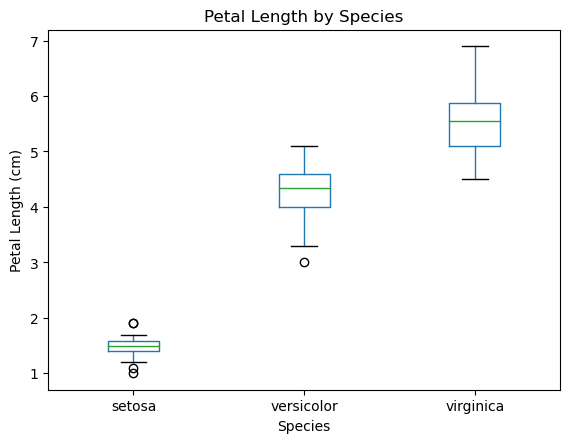

In [10]:
import matplotlib.pyplot as plt
import plotly.express as px
# Matplotlib Visualization
boxplot = iris.boxplot(column='petal_length', by='species', grid=False)
plt.title('Petal Length by Species')
plt.suptitle('')
plt.xlabel('Species')   
plt.ylabel('Petal Length (cm)')
plt.show()

해석 : setosa는 Q1~Q3가 1.2~1.8 수준으로 변동성이 가장 작다. 
versicolor는 setosa보다 petal length가 전반적으로 크고, 분포 범위가 넓다. 
virginiva는 중앙값이 가장 크고, 분포 범위가 가장 넓어 변동성이 가장 큰 종임을 알 수 있다. 

전체적으로 petal length는 setosa < versicolor < virginica 순으로 크며, 종 간의 차이가 명확하다.

#4 정규성 검정 

H0 : 데이터(setosa/versicolor/virginica)는 정규분포를 따른다. \\

H1 : 데이터는 정규분포를 따르지 않는다. 

In [18]:
from scipy.stats import shapiro

alpha = 0.05
for sp, sub in iris.groupby('species'):
    stat, p = shapiro(sub['petal_length'])
    if p > alpha:
        print(f"- {sp:10s} | p-value = {p:.3f} | 데이터는 정규분포를 따른다. (fail to reject H0)")
    else:
        print(f"- {sp:10s} | p-value = {p:.3f} | 데이터는 정규분포를 따르지 않는다. (reject H0)")




- setosa     | p-value = 0.055 | 데이터는 정규분포를 따른다. (fail to reject H0)
- versicolor | p-value = 0.158 | 데이터는 정규분포를 따른다. (fail to reject H0)
- virginica  | p-value = 0.110 | 데이터는 정규분포를 따른다. (fail to reject H0)


#5 등분산성 검정
H0 : 세 집단의 분산은 같다.
H1 : 적어도 한 그룹의 분산은 다르다. 

In [22]:
from scipy.stats import levene  
alpha = 0.05
setosa = iris.loc[iris['species']=='setosa', 'petal_length']
versicolor = iris.loc[iris['species']=='versicolor', 'petal_length']
virginica = iris.loc[iris['species']=='virginica', 'petal_length']

stat, p = levene(setosa, versicolor, virginica)
if p > alpha:
    print(f"- {stat:.4f} | p-value = {p:.5f} | 세 집단의 분산은 같다. (fail to reject H0)")
else:
    print(f"- {stat:.4f} | p-value = {p:.5f} | 적어도 한 그룹의 분산은 다르다. (reject H0)")

- 19.4803 | p-value = 0.00000 | 적어도 한 그룹의 분산은 다르다. (reject H0)


#6 ANOVA 검정 수립 
H0 : 세 species 간 평균은 동일하다. 
H1 : 적어도 한 그룹의 평균은 다르다. 

#7 One-way ANOVA

In [31]:
from scipy import stats
stat, val = stats.f_oneway(setosa, versicolor, virginica)
alpha = 0.05
if val > alpha:
    print(f"- F-statistic = {stat:.4f} | p-value = {val:.5f} | 세 집단의 평균은 같다. (fail to reject H0)")
else:
    print(f"- F-statistic = {stat:.4f} | p-value = {val:.5f} | 적어도 한 그룹의 평균은 다르다. (reject H0)")

print(stat)
print(val)


- F-statistic = 1180.1612 | p-value = 0.00000 | 적어도 한 그룹의 평균은 다르다. (reject H0)
1180.161182252981
2.8567766109615584e-91


pvalue가 0.05보다 작으므로 귀무가설을 기각한다. 즉, 적어도 한 그룹의 petal length 평균은 다르다는 결론을 얻을 수 있다. 

#8 Turkey HSD 사후검정

In [32]:
import pandas as pd 
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols

tukey = pairwise_tukeyhsd(endog=iris['petal_length'], groups=iris['species'], alpha=0.05)
print(tukey)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1     group2   meandiff p-adj lower  upper  reject
---------------------------------------------------------
    setosa versicolor    2.798   0.0 2.5942 3.0018   True
    setosa  virginica     4.09   0.0 3.8862 4.2938   True
versicolor  virginica    1.292   0.0 1.0882 1.4958   True
---------------------------------------------------------


세 species간 petal_length의 mean은 모든 쌍에서 유의미한 차이를 보인다. 
setosa-virginica 간 평균차이가 가장 크다. 

#9 결과 요약 
1. Boxplot 결과 해석 
petal length는 virginica > versicolor > setosa 순이었다. 

2. Anova 결과 
p-value가 0.05보다 작아 귀무가설 기각 즉, 세 개의 species 간 평균 차이가 통계적으로 유의미한 것으로 확인되었다. 

3. Turkey HSD 사후검정 
모든 쌍에서 유의미한 차이를 보였다. 

1, 2, 3의 결과를 종합할 때, 세 종의 petal length는 통계적으로 유의하게 차이가 난다고 할 수 있다. 

#10 회귀분석

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
regression = ols('petal_length ~ C(species)', data=iris).fit
x = iris[['sepal_length', 'sepal_width', 'petal_width']]
y = iris['petal_length']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model= LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2= r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse:.4f}')
print(f'R-squared: {r2:.4f}')
coefficients = pd.DataFrame({'Feature': x.columns, 'Coefficient': model.coef_})
print(coefficients)

Mean Squared Error: 0.1300
R-squared: 0.9603
        Feature  Coefficient
0  sepal_length     0.722815
1   sepal_width    -0.635816
2   petal_width     1.467524


해석 : mse는 0.13정도로, 예측값과 실제값 간의 오차가 비교적 작음을 알 수 있다. R^2는 0.96으로, 이 모형은 petal_length의 약 96%를 설명하고 있어 매우 높은 설명력을 가진다. 

또한 다른 변수들이 고정되어 있다는 가정 하에, sepal_length가 1 증가할 때 petal_length는 약 0.72만큼 증가하는 경향을 
sepal_width가 1 증가할 때 petal_length는 약 0.64만큼 감소하는 경향을 
petal_width가 1 증가할 때 petal_length는 약 1.47만큼 증가하는 경향을 보였다. 종합하면 petal_width가 petal_length를 설명하는 데 가장 중요한 변수이다. 